<a href="https://colab.research.google.com/github/Escalada-Matthew/CPE-311/blob/main/SW10_1_CPE311_Escalada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Meet with your partner, revisit your earleir submission and review. Answer this reflective question: "What could you have done better?"


I could have done a better job on trasnformation  and load. I lack the creativity to visualize it in a better way using seaborn

2. Demonstrate an extract, transform, and load on the RT-IoT2022 dataset Download RT-IoT2022 datasetand deliver insights. When demonstrating and extract insights, feel free to utilize these guide questions to help you derive the right insights.

Guide Questions
* What is the distribution of the Attack_type classes (normal vs. various attacks), and what percentage of the 123,117 instances does each class comprise?

* How do the categorical features proto (protocol) and service vary across different attack types and normal traffic patterns? Links to an external site.

* What are the mean and standard deviation of flow_duration for each Attack_type, and are differences statistically significant?

* Which continuous features (e.g., fwd_pkts_per_sec, bwd_pkts_per_sec, payload_bytes_per_second) exhibit the highest correlation with specific attack classes?

* How do time‑based features like fwd_iat.avg and bwd_iat.avg (mean inter‑arrival times) differ between various attack types and normal traffic?

* Which network flag counts (e.g., flow_SYN_flag_count, flow_RST_flag_count, fwd_PSH_flag_count) are most indicative of specific intrusion patterns?




3. After answering the guide questions, create a simple 6-slide presentation (excluding the cover slide) that introduces the dataset (max 1 slide), what did you do (max 1 slide), and what insights were you able to derive (max 4 slides)? Make sure to include your recommendations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
#Extraction
df = pd.read_csv('/content/RT_IOT2022.csv')
print(f"{df.shape[0]} rows and {df.shape[1]} columns.")

123117 rows and 85 columns.


In [4]:
#Transformation

#checking the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   no                        123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio             123117 non-null  f

In [5]:
print(df['service'].value_counts())

service
-         102861
dns         9753
mqtt        4132
http        3464
ssl         2663
ntp          121
dhcp          50
irc           43
ssh           28
radius         2
Name: count, dtype: int64


In [6]:
#Checks whole dataset for nulls
dataset_nulls = df.isnull().values.any()
print(dataset_nulls)

#The result shows that there are no nulls

False


In [7]:
#Replacing the "-" in service with Unknown
df['service'] = df['service'].replace("-", "Unknown")

print(df['service'].value_counts())

service
Unknown    102861
dns          9753
mqtt         4132
http         3464
ssl          2663
ntp           121
dhcp           50
irc            43
ssh            28
radius          2
Name: count, dtype: int64


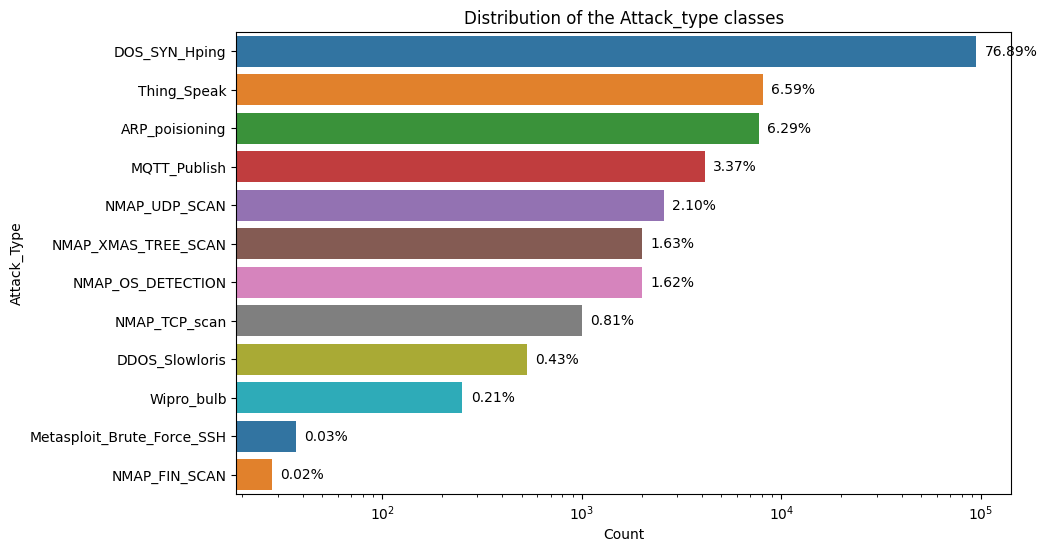

In [8]:
#Load

#Distribution of attack_type
#What is the distribution of the Attack_type classes (normal vs. various attacks),
#and what percentage of the 123,117 instances does each class comprise?

plt.figure(figsize = (10, 6))
attack_count = df['Attack_type'].value_counts()
q1plot = sns.barplot(x=attack_count.values, y=attack_count.index,
                 hue=attack_count.index, palette="tab10", legend=False)
plt.xscale('log')
plt.title('Distribution of the Attack_type classes')
plt.xlabel('Count')
plt.ylabel('Attack_Type')

total = len(df)
for p in q1plot.patches:
  percent = f'{100 * p.get_width() / total:.2f}%'
  x = p.get_width()
  y = p.get_y() + p.get_height() / 2
  q1plot.text (x * 1.1, y, percent, va='center', ha='left')

plt.show()

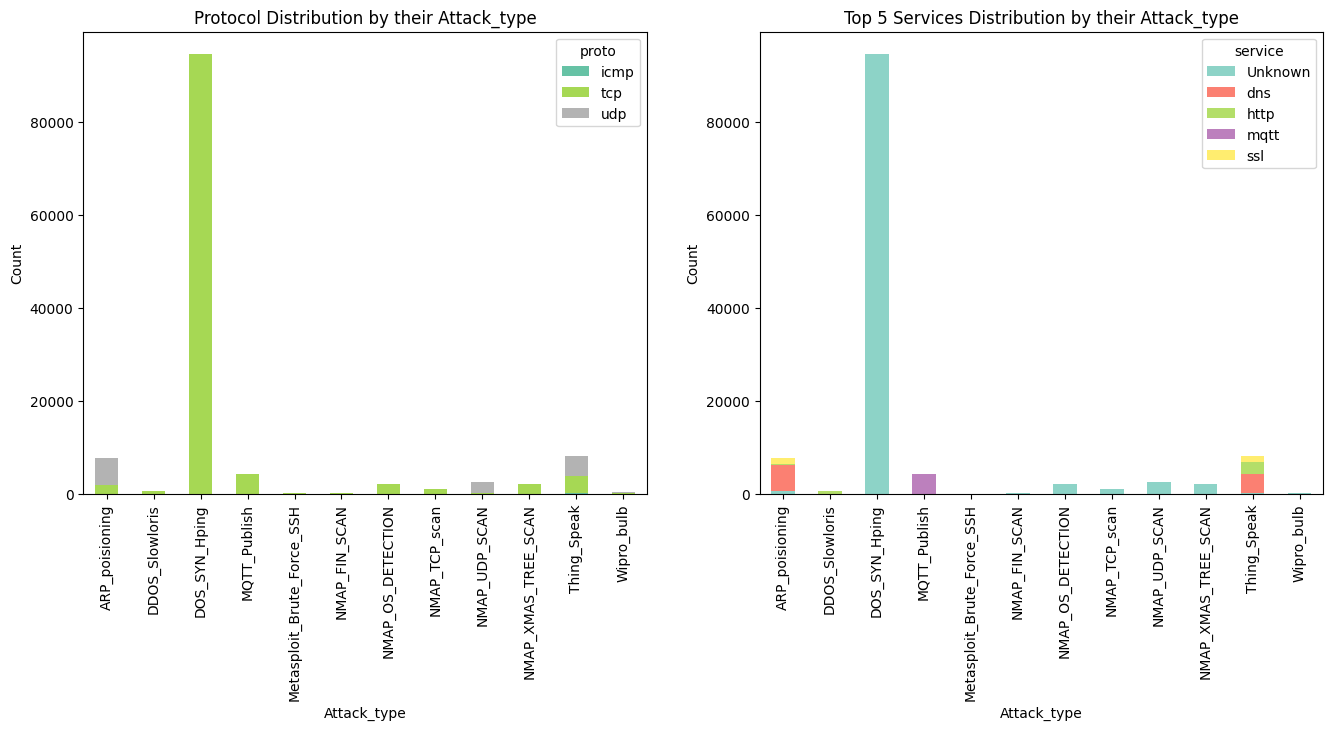

In [9]:
#Proto and service across Attack_type
#How do the categorical features proto (protocol) and service vary across different attack types and normal traffic patterns? Links to an external site.


proto_tab = pd.crosstab(df['Attack_type'], df['proto'])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
proto_tab.plot(kind ='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Protocol Distribution by their Attack_type')
axes[0].set_ylabel('Count')

first_top5 = df['service'].value_counts().head(5).index
service_tab = pd.crosstab(df['Attack_type'], df['service'][df['service'].isin(first_top5)])
service_tab.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
axes[1].set_title('Top 5 Services Distribution by their Attack_type')
axes[1].set_ylabel('Count')

plt.show()

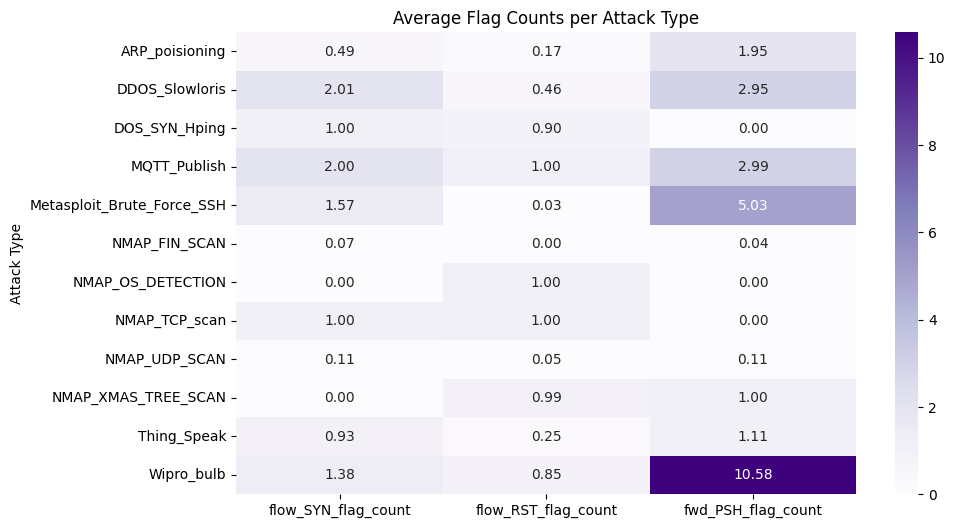

In [12]:
#Flag Count
#Which network flag counts (e.g., flow_SYN_flag_count, flow_RST_flag_count, fwd_PSH_flag_count) are most indicative of specific intrusion patterns?

plt.figure(figsize=(10, 6))
flag_cols = ['flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count']
flag_means = df.groupby('Attack_type')[flag_cols].mean()

sns.heatmap(flag_means, annot=True, fmt=".2f", cmap='Purples')
plt.title('Average Flag Counts per Attack Type')
plt.ylabel('Attack Type')

plt.show()